# CUSTOMER SEGMENTATION

In [1]:
import pandas as pd

rfm = pd.read_csv("outputs/rfm_data.csv")
rfm.head()

,CustomerID,Recency,Frequency,Monetary
0,12346.0,326,1,77183.60
1,12347.0,2,182,4310.00
2,12348.0,75,31,1797.24
3,12349.0,19,73,1757.55
4,12350.0,310,17,334.40


In [2]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm[['Recency', 'Frequency', 'Monetary']])

### find optimal clusters(Elbow method) 

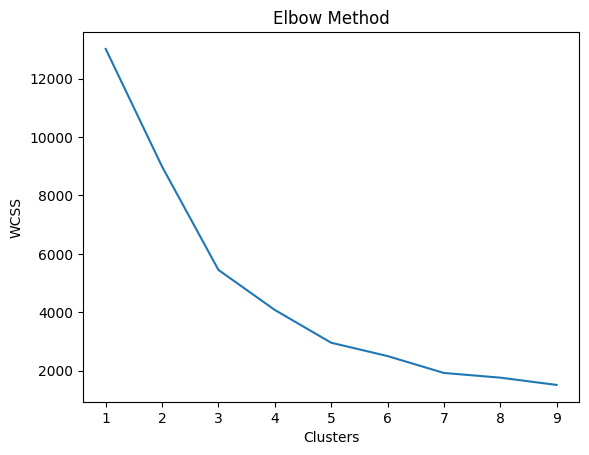

In [4]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
wcss = []
for i in range(1, 10):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(rfm_scaled)
    wcss.append(kmeans.inertia_)

plt.plot(range(1, 10), wcss)
plt.xlabel("Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

### Apply K-Means

In [6]:
kmeans = KMeans(n_clusters=4, random_state=42)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)
rfm.head()

,CustomerID,Recency,Frequency,Monetary,Cluster
0,12346.0,326,1,77183.60,1
1,12347.0,2,182,4310.00,0
2,12348.0,75,31,1797.24,0
3,12349.0,19,73,1757.55,0
4,12350.0,310,17,334.40,2


In [7]:
#check cluster behavior
rfm.groupby('Cluster')[['Recency','Frequency','Monetary']].mean

<bound method GroupBy.mean of <pandas.core.groupby.generic.DataFrameGroupBy object at 0x0000029B5DCC7D90>>

### Assign lables

In [9]:
def segment_name(x):
    if x == 0:
        return "High Value"
    elif x == 1:
        return "Regular"
    elif x == 2:
        return "At Risk"
    else:
        return "Low Value"
rfm['Segment'] = rfm['Cluster'].apply(segment_name)
rfm.head()

,CustomerID,Recency,Frequency,Monetary,Cluster,Segment
0,12346.0,326,1,77183.60,1,Regular
1,12347.0,2,182,4310.00,0,High Value
2,12348.0,75,31,1797.24,0,High Value
3,12349.0,19,73,1757.55,0,High Value
4,12350.0,310,17,334.40,2,At Risk


In [10]:
#creating chrun column 
rfm['Churn'] = rfm['Recency'].apply(lambda x:1 if x>100 else 0)

### churn prediction model

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
X = rfm[['Recency', 'Frequency', 'Monetary']]
y = rfm['Churn']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
model = LogisticRegression()
model.fit(X_train, y_train)

print("Accuracy:", model.score(X_test, y_test))

Accuracy: 1.0


In [14]:
rfm.to_csv("outputs/rfm_final.csv", index=False) #SAVING FILES